In [ ]:
import numpy as np
import scipy.stats as stats
from scipy.optimize import curve_fit
import scipy.signal as signal
from jaxtyping import Float
import pandas as pd
import matplotlib.pyplot as plt

# muutils
from muutils.dbg import dbg, dbg_tensor
from muutils.jsonlines import jsonl_write, jsonl_load

# attention-motifs
from attention_motifs.bins import Bins
from attention_motifs.features import scalar_feature_table, prefix_dict
from attention_motifs.math import compute_envelope_params
from attention_motifs.transition_tensor import transition_tensor

In [19]:
def vec_features(
	arr: np.ndarray,
	compute_distribution: bool = True,
	compute_timeseries: bool = True,
) -> dict[str, float]:
	if len(arr.shape) != 1:
		dbg_tensor(arr)
		raise ValueError(f"Input arr must be 1-dimensional, got {arr.shape}")

	n: int = arr.size

	dist_features: dict[str, float] = dict()
	timeseries_features: dict[str, float] = dict()

	if compute_distribution:
		dbg_tensor(arr)
		bins: int = 10 if n >= 10 else n
		hist, _ = np.histogram(arr, bins=bins)
		probs: np.ndarray = (
			hist.astype(float) / hist.sum() if hist.sum() > 0 else hist.astype(float)
		)
		dist_features = dict(
			mean=np.mean(arr),
			median=np.median(arr),
			variance=np.var(arr, ddof=1),
			std=np.std(arr, ddof=1),
			skewness=stats.skew(arr),
			kurtosis=stats.kurtosis(arr),
			entropy=stats.entropy(probs, base=2),
			L1_norm=np.sum(np.abs(arr)) / n,
			L2_norm=np.linalg.norm(arr, ord=2) / n,
			rms=np.sqrt(np.mean(arr**2)),
			energy=np.sum(arr**2),
		)

	if compute_timeseries:
		# Lag-1 Autocorrelation (Pearson correlation between arr[:-1] and arr[1:])
		autocorr_lag1: float = (
			np.corrcoef(arr[:-1], arr[1:])[0, 1]
			if np.std(arr[:-1]) > 0 and np.std(arr[1:]) > 0
			else 0.0
		)

		# PSD using Welch's method (total power)
		freqs, psd_vals = signal.welch(arr, nperseg=n)
		psd_total_power: float = np.sum(psd_vals)

		# Linear regression using scipy.stats.linregress
		t: np.ndarray = np.arange(n)
		linreg_result = stats.linregress(t, arr)
		line_fit: dict[str, float] = dict(
			slope=linreg_result.slope,
			intercept=linreg_result.intercept,
			r2=linreg_result.rvalue**2,
		)

		timeseries_features: dict[str, float] = dict(
			zero_crossing_rate=np.sum(np.diff(np.signbit(arr))) / (n - 1),
			autocorr_lag1=autocorr_lag1,
			psd_total_power=psd_total_power,
			**{f"linreg.{k}": v for k, v in line_fit.items()},
		)

	return {**dist_features, **timeseries_features}

In [20]:
def scaled_beta(x: np.ndarray, alpha: float, beta: float, scale: float) -> np.ndarray:
	"""Scaled beta distribution."""
	return stats.beta.pdf(x, alpha, beta) * scale


def hist_beta_fit(
	x: Float[np.ndarray, " k"],
	bins: Bins,
) -> dict[str, float]:
	dbg_tensor(x)
	x_hist, _ = np.histogram(x, bins.edges, density=True)
	dbg_tensor(x_hist)

	alpha_est, beta_est, loc, scale = stats.beta.fit(x, method="MM")

	output: dict[str, float] = dict(
		alpha=alpha_est,
		beta=beta_est,
		loc=loc,
		scale=scale,
		**prefix_dict(
			vec_features(x_hist),
			prefix=["hist", "raw"],
		),
		**prefix_dict(
			vec_features(x_hist - scaled_beta(bins.centers, alpha_est, beta_est, scale)),
			prefix=["hist", "diff"],
		),
	)
	
	return output

In [37]:
def skew_lt(
	L: Float[np.ndarray, "n n"],
) -> Float[np.ndarray, "n n"]:
	"""Shift rows of a lower-triangular matrix so that its diagonal becomes the rightmost column.

	# Parameters:
	 - `L : Float[np.ndarray, "n n"]`
	   A square lower-triangular matrix of shape `(n, n)`.

	# Returns:
	 - `Float[np.ndarray, "n n"]`
	   A matrix of shape `(n, n)` with rows shifted so the original diagonal is in the rightmost column.
	"""
	n: int = L.shape[0]
	S: Float[np.ndarray, "n n"] = np.zeros_like(L)
	i, j = np.tril_indices(n)  # row indices i, col indices j of the lower triangle
	S[i, j + (n - i - 1)] = L[i, j]  # shift columns so diagonal ends up at column n-1
	return S


def gram_features(A: Float[np.ndarray, "n_ctx n_ctx"]) -> dict[str, float]:
	dbg_tensor(A)
	plt.matshow(A)
	plt.show()
	return prefix_dict(
		hist_beta_fit(
			A.flatten(),
			bins=Bins(n_bins=32, start=0.0, stop=1.0),
		),
		prefix="beta_hist",
	)
	# TODO: mass as a function of distance from diagonal

def cosine_similarity_matrix(
    X: Float[np.ndarray, "n n"],
    col: bool = False,
    eps: float = 1e-10
) -> np.ndarray:
    # If col==True, treat columns as vectors (i.e., work on the transposed matrix)
    X_: Float[np.ndarray, "n n"] = X.T if col else X
    
    # Compute the dot product matrix for the chosen vectors (rows of X_)
    dot_product: Float[np.ndarray, "n n"] = X_ @ X_.T

    # Compute the norm of each vector (row) in X_
    norms: Float[np.ndarray, "n"] = np.linalg.norm(X_, axis=1)
    
    # Compute the cosine similarity matrix, adding eps to avoid division by zero
    similarity_matrix: np.ndarray = dot_product / ((norms[:, None] * norms[None, :]) + eps)
    return similarity_matrix

In [38]:
def tt_features(
	A: Float[np.ndarray, "n_ctx n_ctx"],
	p_threshold: float = 0.0,
) -> dict[str, float]:
	idxs, tt, res = transition_tensor(A, exact=100, approx_l10=7.0, approx_pts=100)

	output: dict[str, float] = dict()

	indices_raw = np.apply_along_axis(
		lambda row: np.searchsorted(row, p_threshold, side="right"),
		axis=0,
		arr=tt[:, :, 0],
	)
	idxs_with_inf = np.concatenate((idxs, [1e10]))
	indices_adjusted = np.array(idxs_with_inf[indices_raw], dtype=float)
	# if last element, set to inf
	# indices_adjusted[indices_raw == len(idxs)] = 1e10
	indices_adjusted_l10 = np.log10(indices_adjusted[1:])
	# ax_tt_time.plot(indices_adjusted_l10, "ro")
	output.update(
		prefix_dict(
			vec_features(indices_adjusted_l10),
			prefix="time",
		)
	)
	idxs_x = np.arange(len(indices_adjusted_l10))
	for envtype in ("lower", "upper", "bestfit"):
		m, b, r2 = compute_envelope_params(
			x=idxs_x,
			y=indices_adjusted_l10,
			envelope_type=envtype,
		)
		output.update(
			prefix_dict(
				dict(
					slope=m,
					intercept=b,
					r2=r2,
				),
				prefix=["env", envtype],
			)
		)

	indices_adjusted_diff = np.diff(indices_adjusted)
	output.update(
		prefix_dict(
			vec_features(indices_adjusted_diff),
			prefix="diff",
		)
	)

	return output

In [39]:
def compute_scalar_features(
	A: Float[np.ndarray, "n_ctx n_ctx"],
) -> dict[str, float]:
	# dbg_tensor(A)
	plt.matshow(A)
	plt.show()
	
	A_log: Float[np.ndarray, "n_ctx n_ctx"] = np.nan_to_num(np.log(A + 1e-9), nan=-10)
	# dbg_tensor(A_log)

	A_skew: Float[np.ndarray, "n_ctx n_ctx"] = skew_lt(A)
	dbg_tensor(A_skew)
	plt.matshow(A_skew)
	plt.show()
	A_log_skew: Float[np.ndarray, "n_ctx n_ctx"] = skew_lt(A_log)

	return dict(
		# diagonal: standard features, fit diff to beta dist
		**prefix_dict(vec_features(A.diagonal()), prefix="diag"),
		# off-diagonal: standard features, fit diff to beta dist
		**prefix_dict(vec_features(A[:, 0]), prefix="first_tok"),
		# transition tensor: standard features, standard features on diff, linear envelope on transition time
		# 	TODO: standard features on decay rate
		**prefix_dict(
			tt_features(A),
			prefix="markov_transition",
		),
		# {log, raw} gram matrix of {rows, cols, rows of skewed}: beta fit hist
		# 	TODO: fit fft in `gram_features`, but this is expensive
		**prefix_dict(
			gram_features(A @ A.T),
			prefix=["gram", "row"],
		),
		**prefix_dict(
			gram_features(A.T @ A),
			prefix=["gram", "col"],
		),
		**prefix_dict(
			gram_features(A_skew.T @ A_skew),
			prefix=["gram", "skew"],
		),
		**prefix_dict(
			gram_features(cosine_similarity_matrix(A_log)),
			prefix=["log", "gram", "row"],
		),
		**prefix_dict(
			gram_features(cosine_similarity_matrix(A_log, col=True)),
			prefix=["log", "gram", "col"],
		),
		**prefix_dict(
			gram_features(cosine_similarity_matrix(A_log_skew)),
			prefix=["log", "gram", "skew"],
		),
	)

models: ['pythia-14m', 'gemma-2b', 'gpt2-small', 'pythia-1b', 'gpt2-medium', 'tiny-stories-1M']
model: 'pythia-14m'
✔️  (0.00s) setting up paths                                                   
✔️  (0.00s) loading prompts                                                    
128 prompts loaded


prompts:   0%|          | 0/128 [00:00<?, ?it/s]

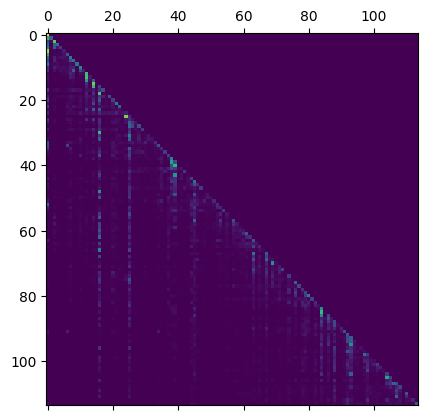

[ <ipykernel>:12 -> compute_scalar_features ] A_skew: μ=0.01 σ=0.04 x̃=0.00 R=[0.00,1.00] ℙ=|█▃▂▂▂▁ | shape=(114,114) dtype=float32


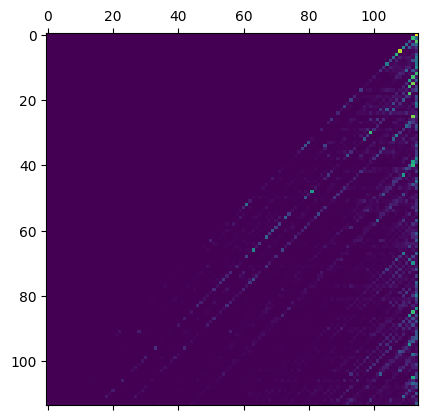

[ <ipykernel>:16 -> vec_features ] arr: μ=0.17 σ=0.16 x̃=0.13 R=[0.00,1.00] ℙ=|█▇▅▃▁▁▁| shape=114 dtype=float32
[ <ipykernel>:16 -> vec_features ] arr: μ=0.08 σ=0.17 x̃=0.01 R=[0.00,1.00] ℙ=|█▄▂▁▁ ▁| shape=114 dtype=float32
[ <ipykernel>:16 -> vec_features ] arr: μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] ℙ=|   █   | shape=113 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=0.01 σ=0.09 x̃=0.00 R=[0.00,1.00] ℙ=|█     ▁| shape=113 dtype=float64
[ <ipykernel>:22 -> gram_features ] A: μ=0.03 σ=0.05 x̃=0.01 R=[0.00,1.00] ℙ=|█▄▃▂▁ ▁| shape=(114,114) dtype=float32


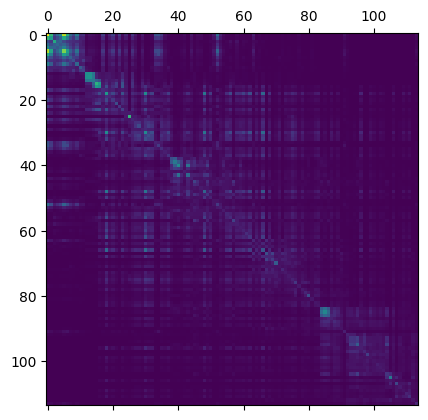

[ <ipykernel>:10 -> hist_beta_fit ] x: μ=0.03 σ=0.05 x̃=0.01 R=[0.00,1.00] ℙ=|█▄▃▂▁ ▁| shape=12996 dtype=float32
[ <ipykernel>:12 -> hist_beta_fit ] x_hist: μ=20.14 σ=23.35 x̃=8.86 R=[0.00,89.57] ℙ=|█▃▃▅▁▁▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=20.14 σ=23.35 x̃=8.86 R=[0.00,89.57] ℙ=|█▃▃▅▁▁▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=20.14 σ=23.35 x̃=8.86 R=[0.00,89.57] ℙ=|█▃▃▅▁▁▁| shape=32 dtype=float64
[ <ipykernel>:22 -> gram_features ] A: μ=0.01 σ=0.06 x̃=0.00 R=[0.00,3.91] ℙ=|█▁▁    | shape=(114,114) dtype=float32


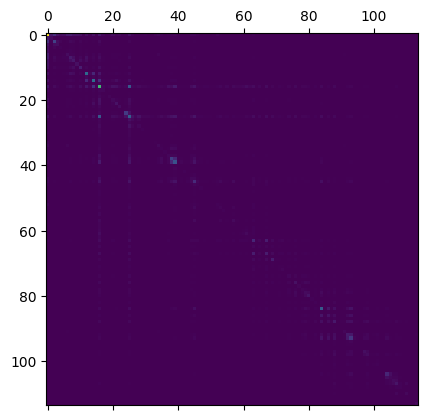

[ <ipykernel>:10 -> hist_beta_fit ] x: μ=0.01 σ=0.06 x̃=0.00 R=[0.00,3.91] ℙ=|█▁▁    | shape=12996 dtype=float32
[ <ipykernel>:12 -> hist_beta_fit ] x_hist: μ=39.32 σ=85.48 x̃=1.90 R=[0.00,439.56] ℙ=|█▃▂   ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=39.32 σ=85.48 x̃=1.90 R=[0.00,439.56] ℙ=|█▃▂   ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=36.53 σ=87.50 x̃=1.90 R=[-63.82,439.56] ℙ=|█▅▃▁  ▁| shape=32 dtype=float64
[ <ipykernel>:22 -> gram_features ] A: μ=0.01 σ=0.09 x̃=0.00 R=[0.00,6.37] ℙ=|█▁     | shape=(114,114) dtype=float32


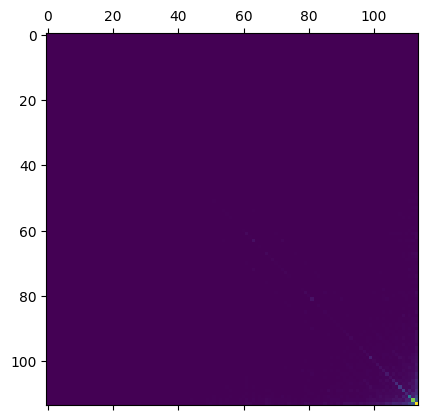

[ <ipykernel>:10 -> hist_beta_fit ] x: μ=0.01 σ=0.09 x̃=0.00 R=[0.00,6.37] ℙ=|█▁     | shape=12996 dtype=float32
[ <ipykernel>:12 -> hist_beta_fit ] x_hist: μ=35.06 σ=105.84 x̃=1.83 R=[0.00,603.99] ℙ=|█▂    ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=35.06 σ=105.84 x̃=1.83 R=[0.00,603.99] ℙ=|█▂    ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=12.73 σ=117.02 x̃=0.00 R=[-100.57,603.97] ℙ=|█▅    ▁| shape=32 dtype=float64
[ <ipykernel>:22 -> gram_features ] A: μ=0.87 σ=0.07 x̃=0.86 R=[0.66,1.00] ℙ=|▄▆▇█▇▇▇| shape=(114,114) dtype=float32


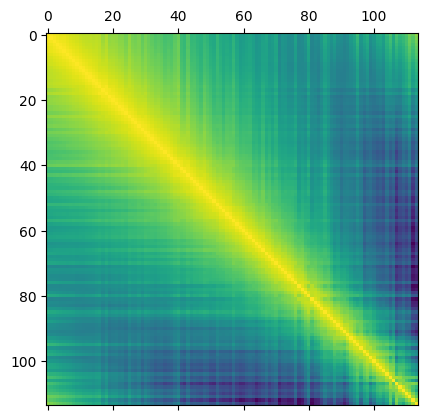

[ <ipykernel>:10 -> hist_beta_fit ] x: μ=0.87 σ=0.07 x̃=0.86 R=[0.66,1.00] ℙ=|▄▆▇█▇▇▇| shape=12996 dtype=float32
[ <ipykernel>:12 -> hist_beta_fit ] x_hist: μ=0.16 σ=0.74 x̃=0.00 R=[0.00,4.14] ℙ=|█▁    ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=0.16 σ=0.74 x̃=0.00 R=[0.00,4.14] ℙ=|█▁    ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=0.02 σ=0.78 x̃=-0.01 R=[-0.69,4.08] ℙ=|█▇▁   ▁| shape=32 dtype=float64
[ <ipykernel>:22 -> gram_features ] A: μ=0.86 σ=0.08 x̃=0.87 R=[0.41,1.00] ℙ=|▁▂▄▆▇█▇| shape=(114,114) dtype=float32


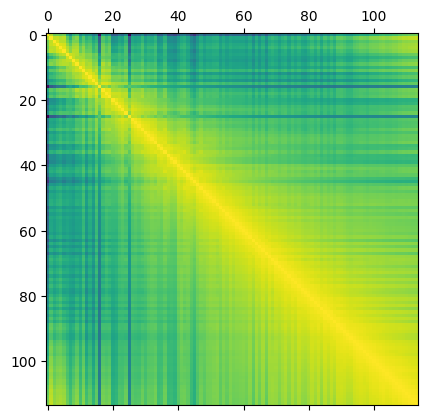

[ <ipykernel>:10 -> hist_beta_fit ] x: μ=0.86 σ=0.08 x̃=0.87 R=[0.41,1.00] ℙ=|▁▂▄▆▇█▇| shape=12996 dtype=float32
[ <ipykernel>:12 -> hist_beta_fit ] x_hist: μ=0.16 σ=0.72 x̃=0.00 R=[0.00,3.96] ℙ=|█ ▁   ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=0.16 σ=0.72 x̃=0.00 R=[0.00,3.96] ℙ=|█ ▁   ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=-0.04 σ=0.17 x̃=-0.00 R=[-0.73,0.03] ℙ=|▂     █| shape=32 dtype=float64
[ <ipykernel>:22 -> gram_features ] A: μ=0.54 σ=0.25 x̃=0.56 R=[0.00,1.00] ℙ=|▇▇▇▇▇█▇| shape=(114,114) dtype=float32


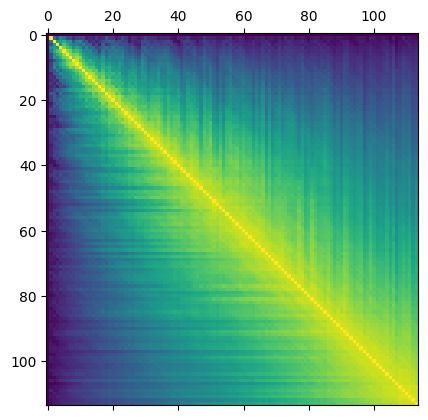

[ <ipykernel>:10 -> hist_beta_fit ] x: μ=0.54 σ=0.25 x̃=0.56 R=[0.00,1.00] ℙ=|▇▇▇▇▇█▇| shape=12996 dtype=float32
[ <ipykernel>:12 -> hist_beta_fit ] x_hist: μ=0.93 σ=3.01 x̃=0.23 R=[0.00,17.51] ℙ=|█     ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=0.93 σ=3.01 x̃=0.23 R=[0.00,17.51] ℙ=|█     ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=0.53 σ=3.05 x̃=-0.03 R=[-0.38,17.50] ℙ=|█     ▁| shape=32 dtype=float64


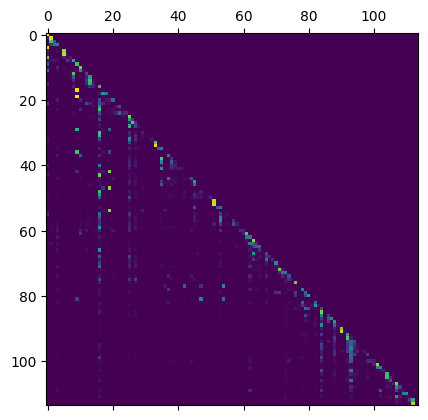

[ <ipykernel>:12 -> compute_scalar_features ] A_skew: μ=0.01 σ=0.06 x̃=0.00 R=[0.00,1.00] ℙ=|█▃▃▃▂▂▂| shape=(114,114) dtype=float32


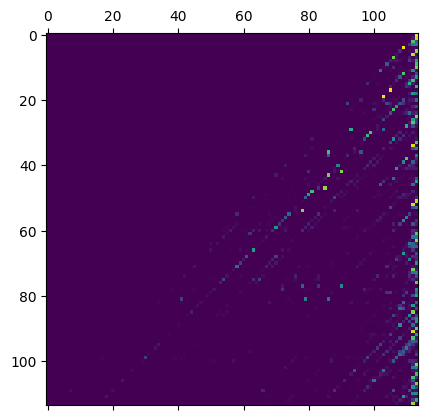

[ <ipykernel>:16 -> vec_features ] arr: μ=0.25 σ=0.28 x̃=0.12 R=[0.00,1.00] ℙ=|█▅▄▄▄▄▂| shape=114 dtype=float32
[ <ipykernel>:16 -> vec_features ] arr: μ=0.04 σ=0.15 x̃=0.00 R=[0.00,1.00] ℙ=|█▁▁  ▁▁| shape=114 dtype=float32
[ <ipykernel>:16 -> vec_features ] arr: μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] ℙ=|   █   | shape=113 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=0.01 σ=0.09 x̃=0.00 R=[0.00,1.00] ℙ=|█     ▁| shape=113 dtype=float64
[ <ipykernel>:22 -> gram_features ] A: μ=0.03 σ=0.08 x̃=0.00 R=[0.00,1.00] ℙ=|█▅▄▃▃▂▂| shape=(114,114) dtype=float32


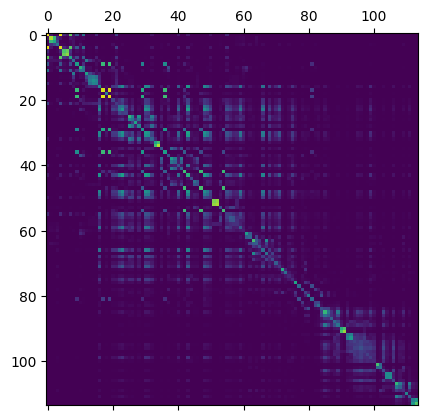

[ <ipykernel>:10 -> hist_beta_fit ] x: μ=0.03 σ=0.08 x̃=0.00 R=[0.00,1.00] ℙ=|█▅▄▃▃▂▂| shape=12996 dtype=float32
[ <ipykernel>:12 -> hist_beta_fit ] x_hist: μ=29.29 σ=71.50 x̃=3.61 R=[0.01,401.66] ℙ=|█▃    ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=29.29 σ=71.50 x̃=3.61 R=[0.01,401.66] ℙ=|█▃    ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=-42.40 σ=67.56 x̃=-7.98 R=[-249.71,0.20] ℙ=|▂▁ ▂▂▃█| shape=32 dtype=float64
[ <ipykernel>:22 -> gram_features ] A: μ=0.01 σ=0.09 x̃=0.00 R=[0.00,5.41] ℙ=|█▂▁    | shape=(114,114) dtype=float32


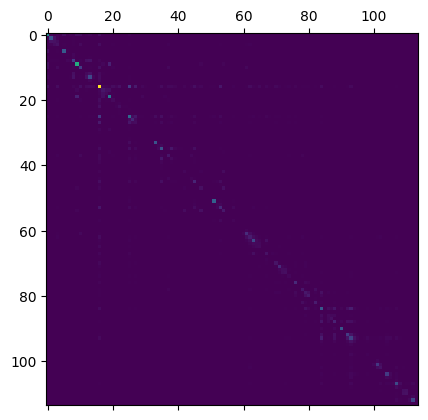

[ <ipykernel>:10 -> hist_beta_fit ] x: μ=0.01 σ=0.09 x̃=0.00 R=[0.00,5.41] ℙ=|█▂▁    | shape=12996 dtype=float32
[ <ipykernel>:12 -> hist_beta_fit ] x_hist: μ=34.29 σ=129.97 x̃=1.27 R=[0.00,748.36] ℙ=|█     ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=34.29 σ=129.97 x̃=1.27 R=[0.00,748.36] ℙ=|█     ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=19.75 σ=144.05 x̃=1.27 R=[-288.85,748.36] ℙ=|▁█▅   ▁| shape=32 dtype=float64
[ <ipykernel>:22 -> gram_features ] A: μ=0.01 σ=0.19 x̃=0.00 R=[0.00,16.27] ℙ=|█▁     | shape=(114,114) dtype=float32


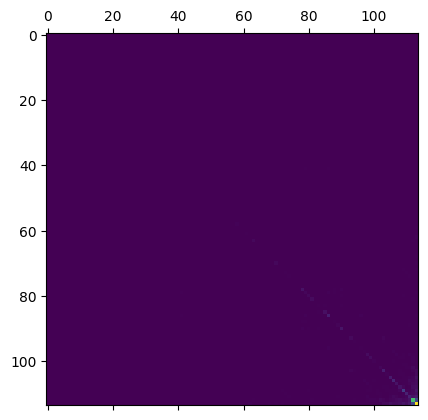

[ <ipykernel>:10 -> hist_beta_fit ] x: μ=0.01 σ=0.19 x̃=0.00 R=[0.00,16.27] ℙ=|█▁     | shape=12996 dtype=float32
[ <ipykernel>:12 -> hist_beta_fit ] x_hist: μ=34.15 σ=136.40 x̃=0.98 R=[0.00,786.64] ℙ=|█     ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=34.15 σ=136.40 x̃=0.98 R=[0.00,786.64] ℙ=|█     ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=22.39 σ=151.47 x̃=0.98 R=[-341.06,786.64] ℙ=|▁▁█   ▁| shape=32 dtype=float64
[ <ipykernel>:22 -> gram_features ] A: μ=0.90 σ=0.05 x̃=0.90 R=[0.73,1.00] ℙ=|▃▅▇▇█▇▇| shape=(114,114) dtype=float32


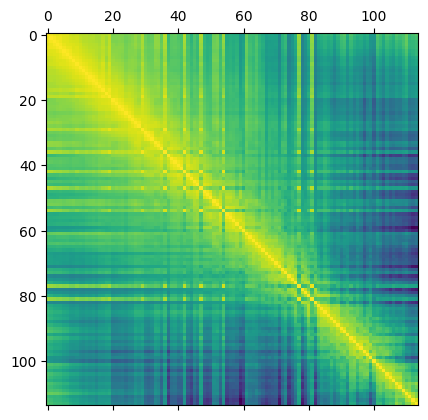

[ <ipykernel>:10 -> hist_beta_fit ] x: μ=0.90 σ=0.05 x̃=0.90 R=[0.73,1.00] ℙ=|▃▅▇▇█▇▇| shape=12996 dtype=float32
[ <ipykernel>:12 -> hist_beta_fit ] x_hist: μ=0.16 σ=0.85 x̃=0.00 R=[0.00,4.87] ℙ=|█     ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=0.16 σ=0.85 x̃=0.00 R=[0.00,4.87] ℙ=|█     ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=0.08 σ=0.85 x̃=-0.00 R=[-0.73,4.72] ℙ=|█     ▁| shape=32 dtype=float64
[ <ipykernel>:22 -> gram_features ] A: μ=0.90 σ=0.06 x̃=0.91 R=[0.53,1.00] ℙ=|▁▃▄▆▇█▇| shape=(114,114) dtype=float32


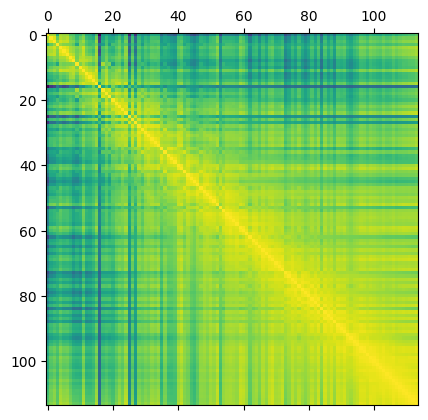

[ <ipykernel>:10 -> hist_beta_fit ] x: μ=0.90 σ=0.06 x̃=0.91 R=[0.53,1.00] ℙ=|▁▃▄▆▇█▇| shape=12996 dtype=float32
[ <ipykernel>:12 -> hist_beta_fit ] x_hist: μ=0.16 σ=0.80 x̃=0.00 R=[0.00,4.61] ℙ=|█     ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=0.16 σ=0.80 x̃=0.00 R=[0.00,4.61] ℙ=|█     ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=-0.05 σ=0.28 x̃=-0.00 R=[-1.58,0.07] ℙ=|▁     █| shape=32 dtype=float64
[ <ipykernel>:22 -> gram_features ] A: μ=0.52 σ=0.25 x̃=0.55 R=[0.00,1.00] ℙ=|▇▇▇▇▇█▆| shape=(114,114) dtype=float32


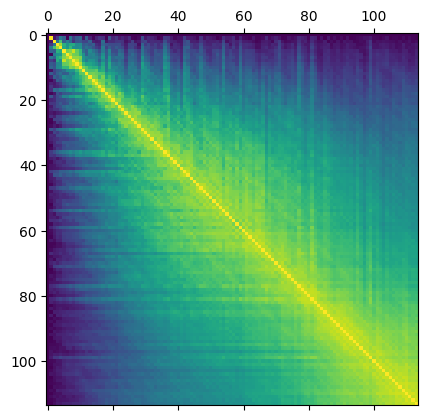

[ <ipykernel>:10 -> hist_beta_fit ] x: μ=0.52 σ=0.25 x̃=0.55 R=[0.00,1.00] ℙ=|▇▇▇▇▇█▆| shape=12996 dtype=float32
[ <ipykernel>:12 -> hist_beta_fit ] x_hist: μ=1.09 σ=2.98 x̃=0.54 R=[0.00,17.52] ℙ=|█     ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=1.09 σ=2.98 x̃=0.54 R=[0.00,17.52] ℙ=|█     ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=0.74 σ=3.02 x̃=0.23 R=[-0.72,17.51] ℙ=|█     ▁| shape=32 dtype=float64


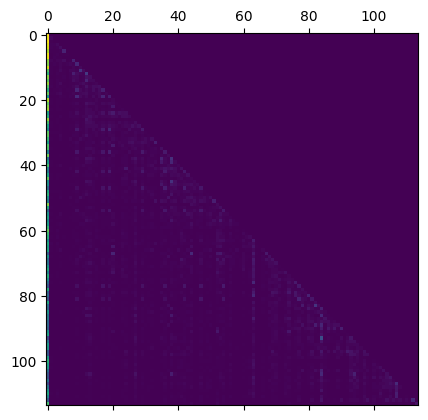

[ <ipykernel>:12 -> compute_scalar_features ] A_skew: μ=0.01 σ=0.06 x̃=0.00 R=[0.00,1.00] ℙ=|█▂▂▂▂▂▂| shape=(114,114) dtype=float32


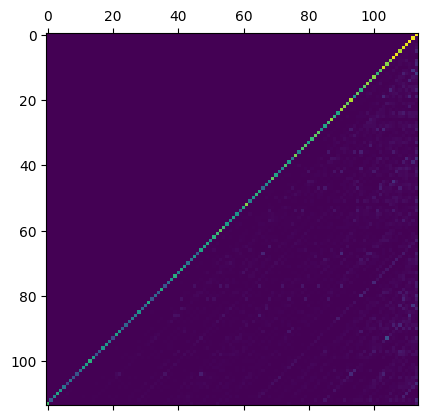

[ <ipykernel>:16 -> vec_features ] arr: μ=0.04 σ=0.10 x̃=0.03 R=[0.00,1.00] ℙ=|█▁    ▁| shape=114 dtype=float32
[ <ipykernel>:16 -> vec_features ] arr: μ=0.58 σ=0.20 x̃=0.57 R=[0.22,1.00] ℙ=|▆▇▇█▇▆▅| shape=114 dtype=float32
[ <ipykernel>:16 -> vec_features ] arr: μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] ℙ=|   █   | shape=113 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=0.01 σ=0.09 x̃=0.00 R=[0.00,1.00] ℙ=|█     ▁| shape=113 dtype=float64
[ <ipykernel>:22 -> gram_features ] A: μ=0.34 σ=0.17 x̃=0.31 R=[0.06,1.00] ℙ=|▇█▇▇▆▅▄| shape=(114,114) dtype=float32


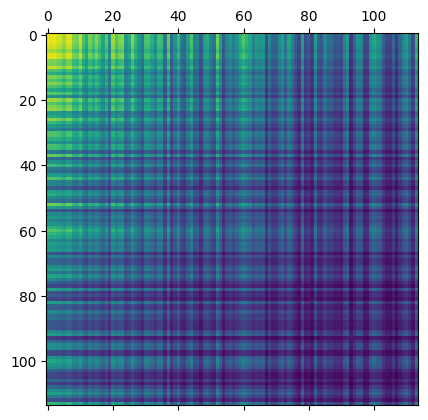

[ <ipykernel>:10 -> hist_beta_fit ] x: μ=0.34 σ=0.17 x̃=0.31 R=[0.06,1.00] ℙ=|▇█▇▇▆▅▄| shape=12996 dtype=float32
[ <ipykernel>:12 -> hist_beta_fit ] x_hist: μ=0.54 σ=0.89 x̃=0.00 R=[0.00,2.69] ℙ=|█▂▁▂ ▂▃| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=0.54 σ=0.89 x̃=0.00 R=[0.00,2.69] ℙ=|█▂▁▂ ▂▃| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=-5.41 σ=9.62 x̃=-0.11 R=[-30.21,2.25] ℙ=|▃▁▁▂▁▃█| shape=32 dtype=float64
[ <ipykernel>:22 -> gram_features ] A: μ=0.01 σ=0.38 x̃=0.00 R=[0.00,42.59] ℙ=|█      | shape=(114,114) dtype=float32


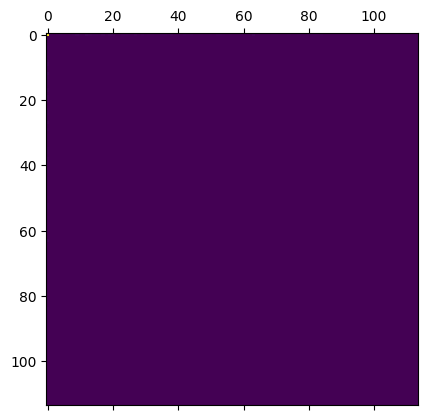

[ <ipykernel>:10 -> hist_beta_fit ] x: μ=0.01 σ=0.38 x̃=0.00 R=[0.00,42.59] ℙ=|█      | shape=12996 dtype=float32
[ <ipykernel>:12 -> hist_beta_fit ] x_hist: μ=44.45 σ=104.73 x̃=0.41 R=[0.00,538.75] ℙ=|█▃▂   ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=44.45 σ=104.73 x̃=0.41 R=[0.00,538.75] ℙ=|█▃▂   ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=44.45 σ=104.73 x̃=0.41 R=[0.00,538.75] ℙ=|█▃▂   ▁| shape=32 dtype=float64
[ <ipykernel>:22 -> gram_features ] A: μ=0.01 σ=0.04 x̃=0.00 R=[0.00,1.24] ℙ=|█▂▂▂▁▁ | shape=(114,114) dtype=float32


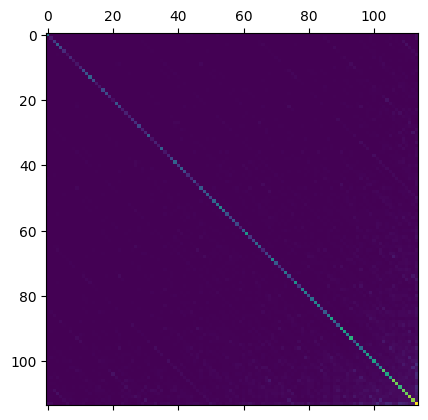

[ <ipykernel>:10 -> hist_beta_fit ] x: μ=0.01 σ=0.04 x̃=0.00 R=[0.00,1.24] ℙ=|█▂▂▂▁▁ | shape=12996 dtype=float32
[ <ipykernel>:12 -> hist_beta_fit ] x_hist: μ=41.20 σ=64.89 x̃=1.93 R=[0.00,227.51] ℙ=|█▂▁▂▂▂▁| shape=32 dtype=float64
/home/miv/projects/attn/attention-motifs/.venv/lib/python3.13/site-packages/scipy/stats/_continuous_distns.py:800: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last five Jacobian evaluations.
  a, b = optimize.fsolve(func, (1.0, 1.0))
[ <ipykernel>:16 -> vec_features ] arr: μ=41.20 σ=64.89 x̃=1.93 R=[0.00,227.51] ℙ=|█▂▁▂▂▂▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=38.86 σ=60.83 x̃=1.53 R=[-0.07,204.32] ℙ=|█▂▁▂▁▃▁| shape=32 dtype=float64
[ <ipykernel>:22 -> gram_features ] A: μ=0.88 σ=0.06 x̃=0.87 R=[0.72,1.00] ℙ=|▄▆█▇▇▇▇| shape=(114,114) dtype=float32


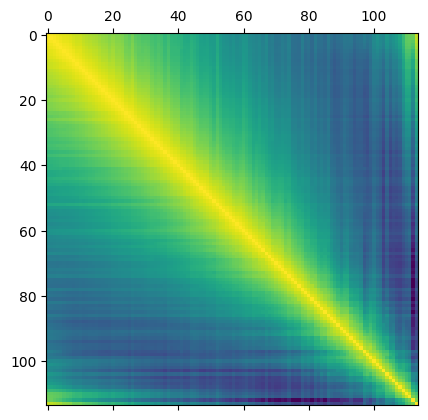

[ <ipykernel>:10 -> hist_beta_fit ] x: μ=0.88 σ=0.06 x̃=0.87 R=[0.72,1.00] ℙ=|▄▆█▇▇▇▇| shape=12996 dtype=float32
[ <ipykernel>:12 -> hist_beta_fit ] x_hist: μ=0.16 σ=0.81 x̃=0.00 R=[0.00,4.68] ℙ=|█     ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=0.16 σ=0.81 x̃=0.00 R=[0.00,4.68] ℙ=|█     ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=-0.71 σ=1.15 x̃=-0.70 R=[-2.68,4.61] ℙ=|▅██   ▂| shape=32 dtype=float64
[ <ipykernel>:22 -> gram_features ] A: μ=0.87 σ=0.07 x̃=0.87 R=[0.44,1.00] ℙ=|▃▃▃▅█▇▇| shape=(114,114) dtype=float32


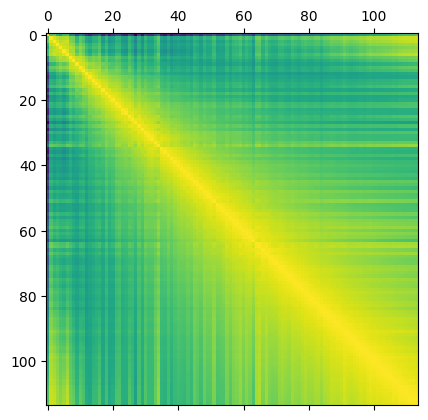

[ <ipykernel>:10 -> hist_beta_fit ] x: μ=0.87 σ=0.07 x̃=0.87 R=[0.44,1.00] ℙ=|▃▃▃▅█▇▇| shape=12996 dtype=float32
[ <ipykernel>:12 -> hist_beta_fit ] x_hist: μ=0.16 σ=0.74 x̃=0.00 R=[0.00,4.16] ℙ=|█▁    ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=0.16 σ=0.74 x̃=0.00 R=[0.00,4.16] ℙ=|█▁    ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=0.16 σ=0.73 x̃=0.00 R=[-0.00,4.09] ℙ=|█▁    ▁| shape=32 dtype=float64
[ <ipykernel>:22 -> gram_features ] A: μ=0.58 σ=0.24 x̃=0.62 R=[0.00,1.00] ℙ=|▆▇▇▇▇█▇| shape=(114,114) dtype=float32


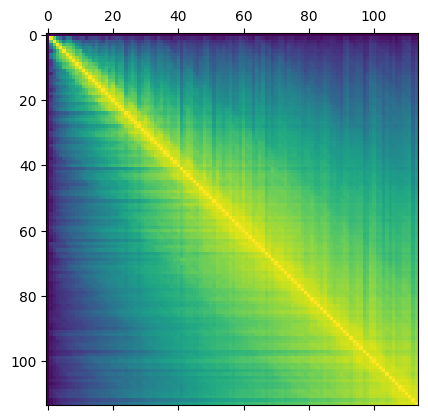

[ <ipykernel>:10 -> hist_beta_fit ] x: μ=0.58 σ=0.24 x̃=0.62 R=[0.00,1.00] ℙ=|▆▇▇▇▇█▇| shape=12996 dtype=float32
[ <ipykernel>:12 -> hist_beta_fit ] x_hist: μ=0.86 σ=3.02 x̃=0.06 R=[0.00,17.52] ℙ=|█     ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=0.86 σ=3.02 x̃=0.06 R=[0.00,17.52] ℙ=|█     ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=0.56 σ=3.05 x̃=-0.00 R=[-0.63,17.52] ℙ=|█     ▁| shape=32 dtype=float64


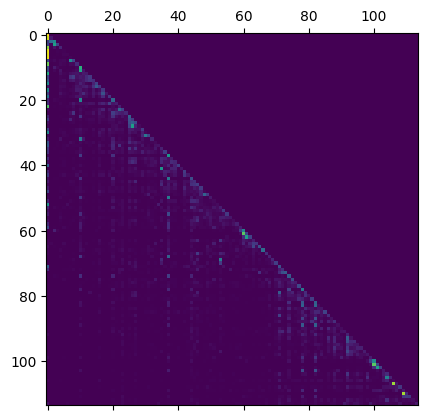

[ <ipykernel>:12 -> compute_scalar_features ] A_skew: μ=0.01 σ=0.04 x̃=0.00 R=[0.00,1.00] ℙ=|█▃▂▂▁▁▁| shape=(114,114) dtype=float32


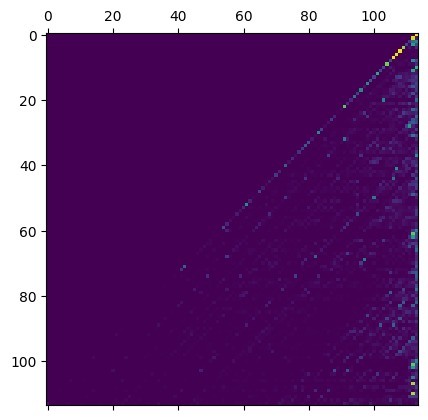

[ <ipykernel>:16 -> vec_features ] arr: μ=0.15 σ=0.14 x̃=0.12 R=[0.01,1.00] ℙ=|█▆▃▃▁ ▁| shape=114 dtype=float32
[ <ipykernel>:16 -> vec_features ] arr: μ=0.14 σ=0.24 x̃=0.03 R=[0.00,1.00] ℙ=|█▅▂▂▁▂▃| shape=114 dtype=float32
[ <ipykernel>:16 -> vec_features ] arr: μ=0.00 σ=0.00 x̃=0.00 R=[0.00,0.00] ℙ=|   █   | shape=113 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=0.01 σ=0.09 x̃=0.00 R=[0.00,1.00] ℙ=|█     ▁| shape=113 dtype=float64
[ <ipykernel>:22 -> gram_features ] A: μ=0.03 σ=0.08 x̃=0.01 R=[0.00,1.00] ℙ=|█▅▃▃▂▂▂| shape=(114,114) dtype=float32


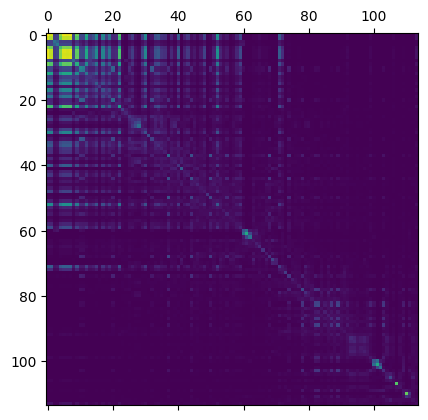

[ <ipykernel>:10 -> hist_beta_fit ] x: μ=0.03 σ=0.08 x̃=0.01 R=[0.00,1.00] ℙ=|█▅▃▃▂▂▂| shape=12996 dtype=float32
[ <ipykernel>:12 -> hist_beta_fit ] x_hist: μ=22.68 σ=30.91 x̃=7.25 R=[0.01,145.89] ℙ=|█▄▅   ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=22.68 σ=30.91 x̃=7.25 R=[0.01,145.89] ℙ=|█▄▅   ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=22.68 σ=30.91 x̃=7.25 R=[0.01,145.89] ℙ=|█▄▅   ▁| shape=32 dtype=float64
[ <ipykernel>:22 -> gram_features ] A: μ=0.01 σ=0.09 x̃=0.00 R=[0.00,9.09] ℙ=|█      | shape=(114,114) dtype=float32


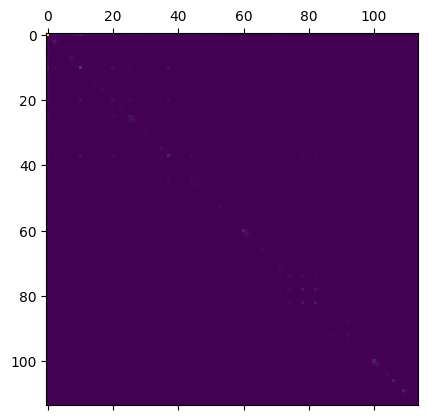

[ <ipykernel>:10 -> hist_beta_fit ] x: μ=0.01 σ=0.09 x̃=0.00 R=[0.00,9.09] ℙ=|█      | shape=12996 dtype=float32
[ <ipykernel>:12 -> hist_beta_fit ] x_hist: μ=39.55 σ=78.02 x̃=2.56 R=[0.00,375.25] ℙ=|█▃▂▁  ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=39.55 σ=78.02 x̃=2.56 R=[0.00,375.25] ℙ=|█▃▂▁  ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=-19.85 σ=346.65 x̃=2.56 R=[-1900.80,375.25] ℙ=|▁    █▅| shape=32 dtype=float64
[ <ipykernel>:22 -> gram_features ] A: μ=0.01 σ=0.09 x̃=0.00 R=[0.00,6.64] ℙ=|█▁     | shape=(114,114) dtype=float32


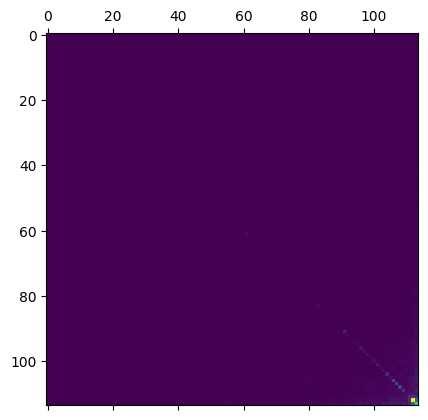

[ <ipykernel>:10 -> hist_beta_fit ] x: μ=0.01 σ=0.09 x̃=0.00 R=[0.00,6.64] ℙ=|█▁     | shape=12996 dtype=float32
[ <ipykernel>:12 -> hist_beta_fit ] x_hist: μ=34.73 σ=106.38 x̃=1.51 R=[0.00,608.18] ℙ=|█▁    ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=34.73 σ=106.38 x̃=1.51 R=[0.00,608.18] ℙ=|█▁    ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=22.69 σ=118.23 x̃=1.51 R=[-205.82,608.18] ℙ=|▂█▅   ▁| shape=32 dtype=float64
[ <ipykernel>:22 -> gram_features ] A: μ=0.87 σ=0.07 x̃=0.86 R=[0.69,1.00] ℙ=|▅▇▇█▇▇▇| shape=(114,114) dtype=float32


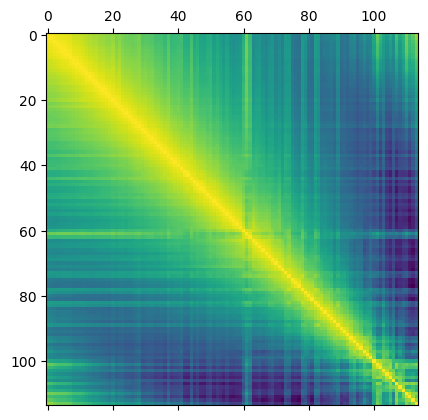

[ <ipykernel>:10 -> hist_beta_fit ] x: μ=0.87 σ=0.07 x̃=0.86 R=[0.69,1.00] ℙ=|▅▇▇█▇▇▇| shape=12996 dtype=float32
[ <ipykernel>:12 -> hist_beta_fit ] x_hist: μ=0.16 σ=0.72 x̃=0.00 R=[0.00,3.98] ℙ=|█ ▁   ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=0.16 σ=0.72 x̃=0.00 R=[0.00,3.98] ℙ=|█ ▁   ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=0.05 σ=0.70 x̃=-0.02 R=[-0.48,3.74] ℙ=|█ ▁   ▁| shape=32 dtype=float64
[ <ipykernel>:22 -> gram_features ] A: μ=0.86 σ=0.08 x̃=0.86 R=[0.40,1.00] ℙ=|▃▄▃▆▇█▇| shape=(114,114) dtype=float32


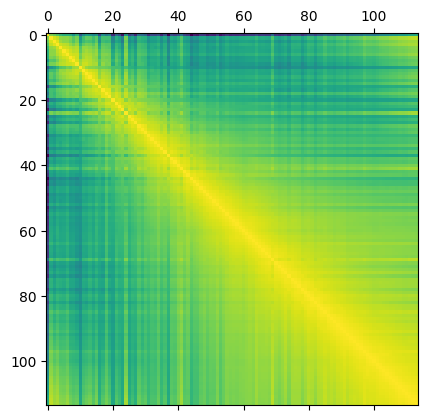

[ <ipykernel>:10 -> hist_beta_fit ] x: μ=0.86 σ=0.08 x̃=0.86 R=[0.40,1.00] ℙ=|▃▄▃▆▇█▇| shape=12996 dtype=float32
[ <ipykernel>:12 -> hist_beta_fit ] x_hist: μ=0.17 σ=0.69 x̃=0.00 R=[0.00,3.75] ℙ=|█ ▁   ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=0.17 σ=0.69 x̃=0.00 R=[0.00,3.75] ℙ=|█ ▁   ▁| shape=32 dtype=float64
[ <ipykernel>:16 -> vec_features ] arr: μ=0.17 σ=0.69 x̃=0.00 R=[0.00,3.75] ℙ=|█ ▁   ▁| shape=32 dtype=float64
[ <ipykernel>:22 -> gram_features ] A: μ=0.53 σ=0.25 x̃=0.55 R=[0.00,1.00] ℙ=|▇▇▇▇█▇▇| shape=(114,114) dtype=float32


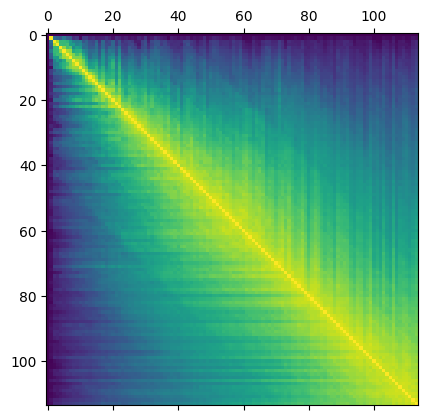

[ <ipykernel>:10 -> hist_beta_fit ] x: μ=0.53 σ=0.25 x̃=0.55 R=[0.00,1.00] ℙ=|▇▇▇▇█▇▇| shape=12996 dtype=float32
[ <ipykernel>:12 -> hist_beta_fit ] x_hist: μ=0.95 σ=3.01 x̃=0.31 R=[0.00,17.53] ℙ=|█     ▁| shape=32 dtype=float64
prompts:   0%|          | 0/128 [00:26<?, ?it/s]


In [ ]:
df: pd.DataFrame = scalar_feature_table(features_func=compute_scalar_features)

In [ ]:
path: str = "../data/scalar_features.jsonl.gz"
jsonl_write(path, df.to_dict(orient="records"), use_gzip=True)

In [ ]:
_temp_loaded = pd.DataFrame(jsonl_load(path))
df = _temp_loaded

In [ ]:
def plot_histograms_long(df: pd.DataFrame) -> None:
	"""Plot histograms for each feature with different models superimposed.

	This function assumes the DataFrame is in long format with columns:
	"model", "feat_name", "feat_val", and optionally "prompt", "layer", "head".

	# Parameters:
	 - `df : pd.DataFrame`
		 DataFrame containing the data.

	# Returns:
	 - `None`
		 Displays the histograms.
	"""
	features: list[str] = df["feat_name"].unique().tolist()
	models: list[str] = df["model"].unique().tolist()

	for feature in features:
		plt.figure()
		subset_feature: pd.DataFrame = df[df["feat_name"] == feature]
		for model in models:
			subset_model: pd.DataFrame = subset_feature[
				subset_feature["model"] == model
			]
			plt.hist(
				subset_model["feat_val"], bins=50, alpha=0.5, label=model, density=True
			)
		plt.xlabel(feature)
		plt.ylabel("Frequency")
		plt.title(f"Histogram of {feature} for different models")
		plt.legend()
		plt.show()


plot_histograms_long(df)